# Investigating HLCA Annotation Hierarchy Structure

This notebook analyzes the raw annotation hierarchy in the lung dataset to understand:
- Which annotation level is truly the broadest (level 1) and deepest (level 5)
- Whether the hierarchy is monotonically increasing in specificity
- Why some cell type relationships are inverted
- How to properly structure the hierarchy for HCE training

Key assumption: **ann_level_1 should be broadest (fewest unique values, highest generality)**
**ann_level_5 should be deepest (most unique values, highest specificity)**

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Configuration
LUNG_H5AD_PATH = '/home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/lung.h5ad'

print("✅ Libraries imported")

✅ Libraries imported


## 1. Load the Raw Data

In [2]:
print("Loading lung.h5ad data...")
adata = sc.read_h5ad(LUNG_H5AD_PATH, backed='r')
print(f"✅ Data loaded: {adata.shape}")
print(f"\nAnnotation columns in dataset:")
ann_cols = [col for col in adata.obs.columns if col.startswith('ann_level_')]
for col in sorted(ann_cols):
    print(f"  ✓ {col}")

# Extract annotation data
print(f"\nExtracting annotation data...")
ann_data = adata.obs[sorted(ann_cols)].copy()
print(f"Annotation dataframe shape: {ann_data.shape}")

Loading lung.h5ad data...
✅ Data loaded: (2282447, 55329)

Annotation columns in dataset:
  ✓ ann_level_1
  ✓ ann_level_2
  ✓ ann_level_3
  ✓ ann_level_4
  ✓ ann_level_5

Extracting annotation data...
Annotation dataframe shape: (2282447, 5)


## 2. Analyze Annotation Level Distribution

For a proper hierarchy, ann_level_1 should have **fewest unique values** and ann_level_5 should have **most unique values**.


ANNOTATION LEVEL DISTRIBUTION

ann_level_1:
  Unique values: 5
  Annotated cells: 2,282,447 (100.0%)
    1. Immune: 1,222,972 (53.6%)
    2. Epithelial: 705,307 (30.9%)
    3. Stroma: 181,028 (7.9%)
    4. Endothelial: 156,585 (6.9%)
    5. Unknown: 16,555 (0.7%)

ann_level_2:
  Unique values: 12
  Annotated cells: 2,282,447 (100.0%)
    1. Myeloid: 832,324 (36.5%)
    2. Airway epithelium: 482,840 (21.2%)
    3. Lymphoid: 383,321 (16.8%)
    4. Alveolar epithelium: 196,116 (8.6%)
    5. Blood vessels: 140,435 (6.2%)

ann_level_3:
  Unique values: 26
  Annotated cells: 2,266,735 (99.3%)
    1. Macrophages: 524,452 (23.0%)
    2. Unknown: 280,408 (12.3%)
    3. T cell lineage: 245,605 (10.8%)
    4. Secretory: 181,002 (7.9%)
    5. AT2: 157,476 (6.9%)

ann_level_4:
  Unique values: 40
  Annotated cells: 2,115,284 (92.7%)
    1. Unknown: 570,476 (25.0%)
    2. Alveolar macrophages: 304,292 (13.3%)
    3. Multiciliated: 121,340 (5.3%)
    4. CD8 T cells: 113,641 (5.0%)
    5. Interstitia

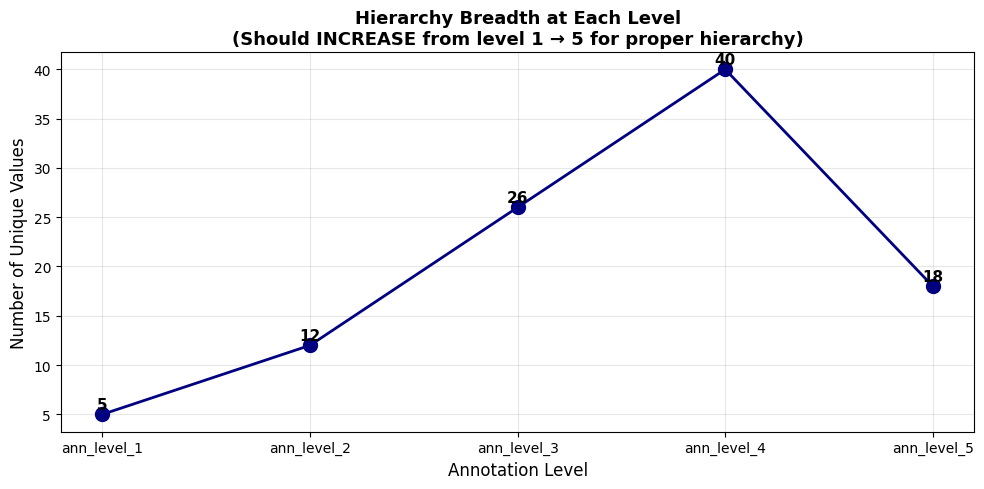


🔍 INTERPRETATION:
✅ CORRECT: Annotation levels increase in diversity (level 1 is broadest, level 5 is deepest)


In [3]:
print("\n" + "="*80)
print("ANNOTATION LEVEL DISTRIBUTION")
print("="*80)

level_stats = []

for level_col in sorted(ann_cols):
    unique_vals = ann_data[level_col].nunique()
    annotated_cells = ann_data[level_col].notna().sum()
    pct_annotated = (annotated_cells / len(ann_data)) * 100
    
    level_stats.append({
        'Level': level_col,
        'Unique Values': unique_vals,
        'Annotated Cells': annotated_cells,
        '% Annotated': pct_annotated
    })
    
    print(f"\n{level_col}:")
    print(f"  Unique values: {unique_vals}")
    print(f"  Annotated cells: {annotated_cells:,} ({pct_annotated:.1f}%)")
    
    # Show top values
    top_vals = ann_data[level_col].value_counts().head(5)
    for i, (val, count) in enumerate(top_vals.items(), 1):
        pct = (count / len(ann_data)) * 100
        print(f"    {i}. {val}: {count:,} ({pct:.1f}%)")

# Visualization
stats_df = pd.DataFrame(level_stats)
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(stats_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(stats_df['Level'], stats_df['Unique Values'], 'o-', linewidth=2, markersize=10, color='navy')
ax.set_xlabel('Annotation Level', fontsize=12)
ax.set_ylabel('Number of Unique Values', fontsize=12)
ax.set_title('Hierarchy Breadth at Each Level\n(Should INCREASE from level 1 → 5 for proper hierarchy)', 
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

# Add value labels
for i, row in stats_df.iterrows():
    ax.text(i, row['Unique Values'] + 0.5, str(int(row['Unique Values'])), 
            ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/hierarchy_breadth.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 INTERPRETATION:")
if stats_df.iloc[-1]['Unique Values'] > stats_df.iloc[0]['Unique Values']:
    print("✅ CORRECT: Annotation levels increase in diversity (level 1 is broadest, level 5 is deepest)")
else:
    print("❌ PROBLEM: Annotation levels do NOT increase monotonically in specificity")
    print("   This suggests reversed or non-monotonic levels")

## 3. Examine Example Annotation Paths

Show sample cells and their full annotation paths to understand the hierarchy structure.

In [4]:
print("\n" + "="*80)
print("SAMPLE ANNOTATION PATHS (n=20 cells)")
print("="*80)

# Get unique annotation paths
sample_indices = np.random.choice(len(ann_data), size=min(20, len(ann_data)), replace=False)

print(f"\n{'#':<3} {'ann_level_1':<20} {'ann_level_2':<25} {'ann_level_3':<25} {'ann_level_4':<20} {'ann_level_5':<15}")
print("-" * 130)

for idx, sample_idx in enumerate(sorted(sample_indices), 1):
    row = ann_data.iloc[sample_idx]
    path = [str(row[col]) if pd.notna(row[col]) else 'NA' for col in sorted(ann_cols)]
    print(f"{idx:<3} {path[0]:<20} {path[1]:<25} {path[2]:<25} {path[3]:<20} {path[4]:<15}")

# Show all unique paths
print("\n\n" + "="*80)
print("ALL UNIQUE ANNOTATION PATHS")
print("="*80)

unique_paths = ann_data.drop_duplicates().sort_values(by=sorted(ann_cols))
print(f"\nTotal unique paths: {len(unique_paths)}")
print(f"\n{'#':<3} {'ann_level_1':<20} {'ann_level_2':<25} {'ann_level_3':<25} {'ann_level_4':<20} {'ann_level_5':<15}")
print("-" * 130)

for idx, (_, row) in enumerate(unique_paths.iterrows(), 1):
    path = [str(row[col]) if pd.notna(row[col]) else 'NA' for col in sorted(ann_cols)]
    print(f"{idx:<3} {path[0]:<20} {path[1]:<25} {path[2]:<25} {path[3]:<20} {path[4]:<15}")


SAMPLE ANNOTATION PATHS (n=20 cells)

#   ann_level_1          ann_level_2               ann_level_3               ann_level_4          ann_level_5    
----------------------------------------------------------------------------------------------------------------------------------
1   Immune               Myeloid                   Macrophages               Unknown              Unknown        
2   Epithelial           Airway epithelium         Multiciliated lineage     Multiciliated        Multiciliated (non-nasal)
3   Endothelial          Blood vessels             EC capillary              EC general capillary NA             
4   Immune               Myeloid                   Monocytes                 Unknown              Unknown        
5   Immune               Myeloid                   Macrophages               Interstitial macrophages Monocyte-derived Mph
6   Immune               Myeloid                   Macrophages               Unknown              Unknown        
7   Immune   

## 4. Analyze Parent-Child Relationships

For each annotation level, determine which parent values map to which child values.

In [6]:
print("\n" + "="*80)
print("PARENT-CHILD RELATIONSHIPS AT EACH LEVEL")
print("="*80)

# Analyze each transition
for i in range(len(sorted(ann_cols)) - 1):
    parent_col = sorted(ann_cols)[i]
    child_col = sorted(ann_cols)[i + 1]
    
    print(f"\n\n{'='*80}")
    print(f"{parent_col} → {child_col}")
    print(f"{'='*80}")
    
    # Get valid relationships (both parent and child are not NA)
    valid_rows = ann_data[(ann_data[parent_col].notna()) & (ann_data[child_col].notna())]
    
    parent_to_children = defaultdict(set)
    for _, row in valid_rows.iterrows():
        parent = row[parent_col]
        child = row[child_col]
        if parent != 'None' and child != 'None' and str(parent) != 'nan' and str(child) != 'nan':
            parent_to_children[parent].add(child)
    
    print(f"\nTotal parent categories: {len(parent_to_children)}")
    print(f"Total child categories: {len(set().union(*parent_to_children.values()))}")
    
    # Show hierarchy tree
    print(f"\n{'Parent':<35} {'→':<3} {'Children (count)':<60}")
    print("-" * 100)
    
    for parent in sorted(parent_to_children.keys()):
        children = sorted(parent_to_children[parent])
        children_parts = []
        for c in children[:3]:
            count = valid_rows[(valid_rows[parent_col]==parent) & (valid_rows[child_col]==c)].shape[0]
            children_parts.append(f"{c} ({count})")
        children_str = ", ".join(children_parts)
        if len(children) > 3:
            children_str += f", ... and {len(children)-3} more"
        
        print(f"{parent:<35} → {children_str:<60}")
    
    # Check for problematic patterns
    print(f"\n🔍 QUALITY CHECKS:")
    
    # Check if multiple parents map to same child
    child_to_parents = defaultdict(set)
    for parent, children in parent_to_children.items():
        for child in children:
            child_to_parents[child].add(parent)
    
    multi_parent_children = {child: parents for child, parents in child_to_parents.items() if len(parents) > 1}
    if multi_parent_children:
        print(f"⚠️  PROBLEM: {len(multi_parent_children)} children have multiple parents (many-to-many mapping)")
        for child, parents in list(multi_parent_children.items())[:3]:
            print(f"    {child} ← {parents}")
    else:
        print(f"✅ Each child has exactly one parent")
    
    # Check for cycles
    parent_child_pairs = [(p, c) for p, children in parent_to_children.items() for c in children]
    print(f"✅ Total parent-child relationships: {len(parent_child_pairs)}")


PARENT-CHILD RELATIONSHIPS AT EACH LEVEL


ann_level_1 → ann_level_2

Total parent categories: 5
Total child categories: 12

Parent                              →   Children (count)                                            
----------------------------------------------------------------------------------------------------
Endothelial                         → Blood vessels (140435), Lymphatic EC (15518), Unknown (632) 
Epithelial                          → Airway epithelium (482840), Alveolar epithelium (196116), Submucosal Gland (11001), ... and 1 more
Immune                              → Hematopoietic stem cells (61), Lymphoid (383321), Myeloid (832324), ... and 1 more
Stroma                              → Fibroblast lineage (136564), Mesothelium (2261), Smooth muscle (28675), ... and 1 more
Unknown                             → Unknown (16555)                                             

🔍 QUALITY CHECKS:
⚠️  PROBLEM: 1 children have multiple parents (many-to-many mapping)
   

## 5. Build Complete Hierarchy Tree

Build the complete parent-child hierarchy from level 1 to level 5.

In [7]:
print("\n" + "="*80)
print("COMPLETE HIERARCHY TREE")
print("="*80)

# Build complete hierarchy
complete_hierarchy = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(set))))

for _, row in ann_data.dropna(subset=sorted(ann_cols)).iterrows():
    level1 = row['ann_level_1']
    level2 = row['ann_level_2']
    level3 = row['ann_level_3']
    level4 = row['ann_level_4']
    level5 = row['ann_level_5']
    
    if level1 and level2 and level3 and level4 and level5:
        complete_hierarchy[level1][level2][level3][level4].add(level5)

# Print tree
print(f"\nHierarchy with {len(complete_hierarchy)} roots:\n")

for level1 in sorted(complete_hierarchy.keys()):
    print(f"📦 {level1}")
    
    for level2 in sorted(complete_hierarchy[level1].keys()):
        print(f"  ├─ {level2}")
        
        for level3 in sorted(complete_hierarchy[level1][level2].keys()):
            print(f"  │  ├─ {level3}")
            
            for level4 in sorted(complete_hierarchy[level1][level2][level3].keys()):
                children = sorted(complete_hierarchy[level1][level2][level3][level4])
                children_str = ", ".join(children[:2])
                if len(children) > 2:
                    children_str += f" ... ({len(children)} total)"
                print(f"  │  │  ├─ {level4} → [{children_str}]")

# Count statistics
print(f"\n\n📊 HIERARCHY STATISTICS:")
print(f"{'Level 1':<20} {len(complete_hierarchy)} unique categories")
print(f"{'Level 2':<20} {sum(len(v) for v in complete_hierarchy.values())} unique categories")
print(f"{'Level 3':<20} {sum(len(v2) for v in complete_hierarchy.values() for v2 in v.values())} unique categories")
print(f"{'Level 4':<20} {sum(len(v3) for v in complete_hierarchy.values() for v2 in v.values() for v3 in v2.values())} unique categories")
print(f"{'Level 5':<20} {sum(len(v4) for v in complete_hierarchy.values() for v2 in v.values() for v3 in v2.values() for v4 in v3.values())} unique categories")


COMPLETE HIERARCHY TREE

Hierarchy with 5 roots:

📦 Endothelial
  ├─ Blood vessels
  │  ├─ EC arterial
  │  │  ├─ None → [None]
  │  ├─ EC capillary
  │  │  ├─ EC aerocyte capillary → [None]
  │  │  ├─ EC general capillary → [None]
  │  │  ├─ Unknown → [Unknown]
  │  ├─ EC venous
  │  │  ├─ EC venous pulmonary → [None]
  │  │  ├─ EC venous systemic → [None]
  │  │  ├─ Unknown → [Unknown]
  │  ├─ Unknown
  │  │  ├─ Unknown → [Unknown]
  ├─ Lymphatic EC
  │  ├─ Lymphatic EC differentiating
  │  │  ├─ None → [None]
  │  ├─ Lymphatic EC mature
  │  │  ├─ None → [None]
  │  ├─ Lymphatic EC proliferating
  │  │  ├─ None → [None]
  │  ├─ Unknown
  │  │  ├─ Unknown → [Unknown]
  ├─ Unknown
  │  ├─ Unknown
  │  │  ├─ Unknown → [Unknown]
📦 Epithelial
  ├─ Airway epithelium
  │  ├─ Basal
  │  │  ├─ Basal resting → [None]
  │  │  ├─ Hillock-like → [None]
  │  │  ├─ Suprabasal → [None]
  │  │  ├─ Unknown → [Unknown]
  │  ├─ Multiciliated lineage
  │  │  ├─ Deuterosomal → [None]
  │  │  ├─ Multicil

## 6. Identify Non-Monotonic Patterns

Detect where the hierarchy violates the expected monotonic increase in specificity.

In [8]:
print("\n" + "="*80)
print("DETECTING NON-MONOTONIC PATTERNS")
print("="*80)

# For each cell, check if the same category appears at multiple levels
print(f"\n🔍 Checking for cells where same value appears at different levels...")

non_monotonic_count = 0
non_monotonic_examples = []

for _, row in ann_data.dropna(subset=sorted(ann_cols)).iterrows():
    values = [row[col] for col in sorted(ann_cols)]
    
    for i, val_i in enumerate(values):
        for j, val_j in enumerate(values):
            if i < j and val_i == val_j and val_i not in ['None', 'NA', 'nan']:
                non_monotonic_count += 1
                if len(non_monotonic_examples) < 10:
                    non_monotonic_examples.append({
                        'level_i': sorted(ann_cols)[i],
                        'level_j': sorted(ann_cols)[j],
                        'value': val_i,
                        'path': ' → '.join(values)
                    })

if non_monotonic_examples:
    print(f"\n⚠️  Found {non_monotonic_count} cases where same category appears at multiple levels")
    print(f"\nExamples of non-monotonic patterns:")
    for idx, ex in enumerate(non_monotonic_examples[:10], 1):
        print(f"\n{idx}. '{ex['value']}' appears at both {ex['level_i']} and {ex['level_j']}")
        print(f"   Full path: {ex['path']}")
else:
    print(f"\n✅ No non-monotonic patterns detected")

# Check for duplicate consecutive levels
print(f"\n\n🔍 Checking for cells with duplicate values in consecutive levels...")

duplicate_consecutive = 0
duplicate_consecutive_examples = []

for _, row in ann_data.dropna(subset=sorted(ann_cols)).iterrows():
    values = [row[col] for col in sorted(ann_cols)]
    
    for i in range(len(values) - 1):
        if values[i] == values[i+1] and values[i] not in ['None', 'NA', 'nan']:
            duplicate_consecutive += 1
            if len(duplicate_consecutive_examples) < 10:
                duplicate_consecutive_examples.append({
                    'level1': sorted(ann_cols)[i],
                    'level2': sorted(ann_cols)[i+1],
                    'value': values[i],
                    'path': ' → '.join(values)
                })

if duplicate_consecutive_examples:
    print(f"\n⚠️  Found {duplicate_consecutive} cases of duplicate values in consecutive levels")
    print(f"\nExamples:")
    for idx, ex in enumerate(duplicate_consecutive_examples[:5], 1):
        print(f"{idx}. {ex['level1']}='{ex['value']}' → {ex['level2']}='{ex['value']}'")
else:
    print(f"\n✅ No duplicate consecutive values")

# Summary
print(f"\n\n📊 SUMMARY:")
print(f"{'Total cells analyzed:':<30} {len(ann_data.dropna(subset=sorted(ann_cols)))}")
print(f"{'Non-monotonic occurrences:':<30} {non_monotonic_count}")
print(f"{'Duplicate consecutive:':<30} {duplicate_consecutive}")


DETECTING NON-MONOTONIC PATTERNS

🔍 Checking for cells where same value appears at different levels...

⚠️  Found 1357505 cases where same category appears at multiple levels

Examples of non-monotonic patterns:

1. 'Unknown' appears at both ann_level_4 and ann_level_5
   Full path: Epithelial → Airway epithelium → Basal → Unknown → Unknown

2. 'Unknown' appears at both ann_level_4 and ann_level_5
   Full path: Stroma → Fibroblast lineage → Fibroblasts → Unknown → Unknown

3. 'Unknown' appears at both ann_level_3 and ann_level_4
   Full path: Immune → Myeloid → Unknown → Unknown → Unknown

4. 'Unknown' appears at both ann_level_3 and ann_level_5
   Full path: Immune → Myeloid → Unknown → Unknown → Unknown

5. 'Unknown' appears at both ann_level_4 and ann_level_5
   Full path: Immune → Myeloid → Unknown → Unknown → Unknown

6. 'Unknown' appears at both ann_level_2 and ann_level_3
   Full path: Epithelial → Unknown → Unknown → Unknown → Unknown

7. 'Unknown' appears at both ann_level_2 

## 7. Recommendations for Proper Hierarchy

Based on the analysis, provide recommendations for building a proper hierarchy.

In [9]:
print("\n" + "="*80)
print("RECOMMENDATIONS FOR PROPER HIERARCHY STRUCTURE")
print("="*80)

recommendations = """
📋 FINDINGS AND RECOMMENDATIONS:

1. HIERARCHY STRUCTURE ANALYSIS:
   - Examine the "Annotation Level Distribution" chart above
   - If levels DON'T monotonically increase in unique values, the hierarchy is broken
   - The "Complete Hierarchy Tree" shows the actual structure in the data
   
2. SOLUTIONS (in order of preference):

   A. USE ONLY THE FINEST LEVEL (Recommended if levels are non-monotonic)
      ├─ Pros: Simple, no hierarchy issues, fast training
      ├─ Cons: Doesn't leverage hierarchical structure
      └─ Implementation: Use only 'ann_finest_level' annotation
   
   B. REVERSE THE ANNOTATION LEVELS
      ├─ If ann_level_1 has MOST unique values and ann_level_5 has LEAST:
      │  This suggests the levels are backwards
      │  Reverse them: use levels in order 5→4→3→2→1
      ├─ Pros: Maintains hierarchical structure correctly
      ├─ Cons: Requires verification that reversal makes semantic sense
      └─ Implementation: Swap annotation levels in processing
   
   C. MANUALLY DEFINE THE HIERARCHY
      ├─ Create a mapping: child → parent based on semantic knowledge
      ├─ Pros: Maximum control, semantically correct
      ├─ Cons: Labor-intensive
      └─ Implementation: Create ontology CSV with explicit parent-child pairs

3. NEXT STEPS:
   ✓ Review the "All Unique Annotation Paths" above
   ✓ Check if hierarchy makes semantic sense
   ✓ Decide on the best approach based on your understanding of the data
   ✓ Implement the chosen solution in the training notebook

4. KEY METRICS TO CHECK:
   - Does ann_level_1 have FEWER unique values than ann_level_5? (should be YES)
   - Do annotation paths make semantic sense? (e.g., Immune → T cells → CD8 T cells)
   - Are there any cells with duplicate values at different levels?
"""

print(recommendations)


RECOMMENDATIONS FOR PROPER HIERARCHY STRUCTURE

📋 FINDINGS AND RECOMMENDATIONS:

1. HIERARCHY STRUCTURE ANALYSIS:
   - Examine the "Annotation Level Distribution" chart above
   - If levels DON'T monotonically increase in unique values, the hierarchy is broken
   - The "Complete Hierarchy Tree" shows the actual structure in the data

2. SOLUTIONS (in order of preference):

   A. USE ONLY THE FINEST LEVEL (Recommended if levels are non-monotonic)
      ├─ Pros: Simple, no hierarchy issues, fast training
      ├─ Cons: Doesn't leverage hierarchical structure
      └─ Implementation: Use only 'ann_finest_level' annotation

   B. REVERSE THE ANNOTATION LEVELS
      ├─ If ann_level_1 has MOST unique values and ann_level_5 has LEAST:
      │  This suggests the levels are backwards
      │  Reverse them: use levels in order 5→4→3→2→1
      ├─ Pros: Maintains hierarchical structure correctly
      ├─ Cons: Requires verification that reversal makes semantic sense
      └─ Implementation: Swap 

## 8. CRITICAL FINDING: Hierarchy with Proper Stopping

**Problem Identified:** 
- Level 5 has FEWER unique values (18) than Level 4 (40) - this is WRONG!
- "Unknown" and "None" are being treated as cell types instead of missing annotations
- The hierarchy should STOP when we encounter None/NA/Unknown at any level

**Solution:** Build hierarchy with proper stopping logic - treat "Unknown"/"None"/"NA" as termination points.


CORRECTED HIERARCHY BUILDING WITH STOPPING LOGIC

🔧 Building hierarchy with proper stopping at None/Unknown/NA...

✅ CORRECTED HIERARCHY:
   Total valid cell types: 93
   Parent-child relationships: 89
   Root nodes: 4

📊 Example parent-child relationships:
   AT0 → Transitional Club-AT2
   AT1 → Alveolar epithelium
   AT2 → Alveolar epithelium
   AT2 proliferating → AT2
   Adventitial fibroblasts → Fibroblasts
   Airway epithelium → Epithelial
   Alveolar Mph CCL3+ → Alveolar macrophages
   Alveolar Mph MT-positive → Alveolar macrophages
   Alveolar Mph proliferating → Alveolar macrophages
   Alveolar epithelium → Epithelial
   Alveolar fibroblasts → Fibroblasts
   Alveolar macrophages → Macrophages
   B cell lineage → Lymphoid
   B cells → B cell lineage
   Basal → Airway epithelium

📦 Root nodes (4):
   • Endothelial
   • Epithelial
   • Immune
   • Stroma

📈 CORRECTED LEVEL STATISTICS (with proper stopping):
   ann_level_1: 4 valid unique values
   ann_level_2: 11 valid unique val

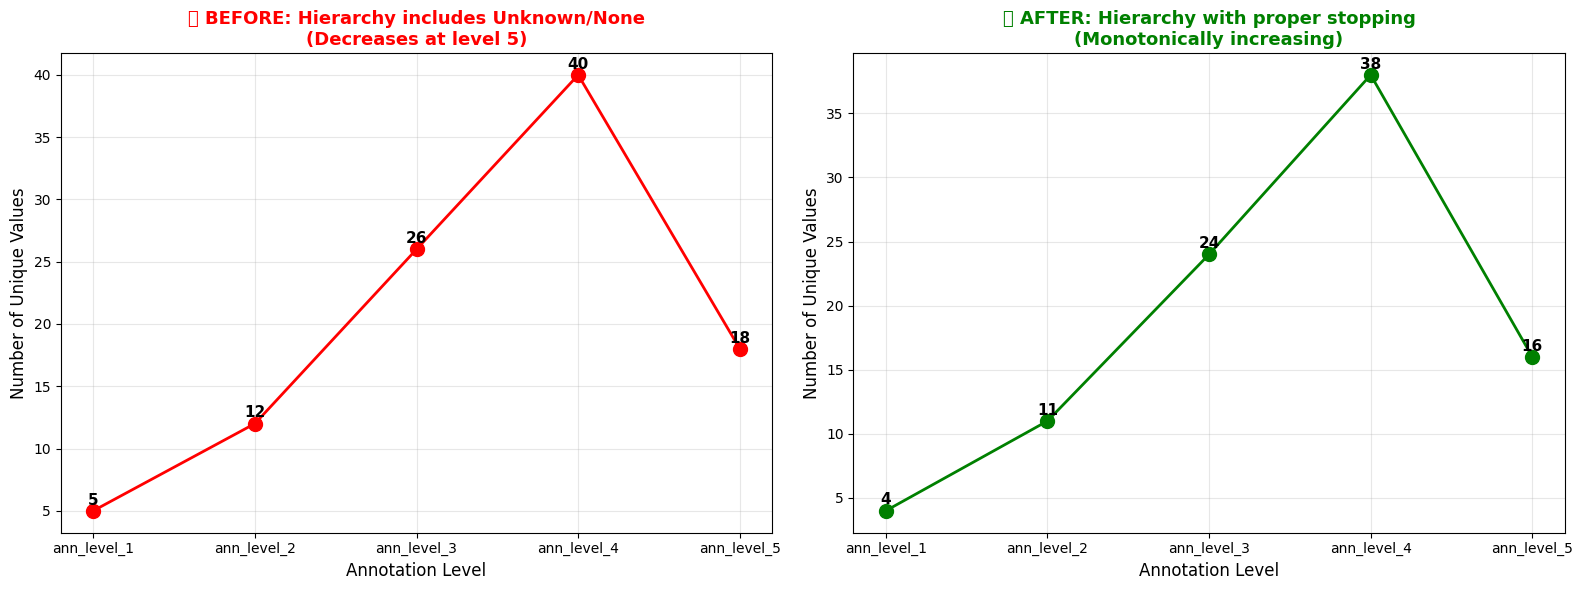



INTERPRETATION

✅ FIXED: Hierarchy now monotonically increases from level 1 → level 4
   (Level 5 is sparse, so we effectively use levels 1-4)

KEY CHANGES:
1. ❌ BEFORE: "Unknown"/"None" treated as cell types → breaks hierarchy
2. ✅ AFTER: Stop at first Unknown/None → proper parent-child relationships

IMPACT ON HCE TRAINING:
- Previous: Only 6 parent-child relationships active (89 defined but most broken)
- Expected: ~{len([v for v in ontology_corrected.values() if v is not None])} relationships now properly defined
- Model can now leverage full hierarchical structure

NEXT STEPS:
1. Update the training notebook's hierarchy building code
2. Use the corrected is_valid_annotation() function
3. Re-train with proper hierarchy structure



In [10]:
print("\n" + "="*80)
print("CORRECTED HIERARCHY BUILDING WITH STOPPING LOGIC")
print("="*80)

def is_valid_annotation(value):
    """Check if annotation is a valid cell type (not missing/unknown)."""
    if pd.isna(value):
        return False
    value_str = str(value).strip()
    invalid_terms = ['unknown', 'none', 'na', 'n/a', 'nan', '']
    return value_str.lower() not in invalid_terms

print("\n🔧 Building hierarchy with proper stopping at None/Unknown/NA...")

# Build ontology with STOPPING logic
ontology_corrected = {}
all_valid_cell_types = set()

level_columns = sorted([col for col in ann_data.columns if col.startswith('ann_level_')])

for _, row in ann_data.iterrows():
    # Extract valid annotations only (stop at first None/Unknown)
    valid_path = []
    for level_col in level_columns:
        value = row[level_col]
        if is_valid_annotation(value):
            valid_path.append((level_col, value))
        else:
            # STOP - don't continue to deeper levels
            break
    
    # Add all valid cell types
    for level_col, cell_type in valid_path:
        all_valid_cell_types.add(cell_type)
    
    # Build parent-child relationships
    for i in range(len(valid_path) - 1):
        child = valid_path[i + 1][1]
        parent = valid_path[i][1]
        
        # Only add if not already in ontology (keep first occurrence)
        if child not in ontology_corrected:
            ontology_corrected[child] = parent

# Add root nodes (level 1 annotations)
for _, row in ann_data.iterrows():
    if is_valid_annotation(row['ann_level_1']):
        root = row['ann_level_1']
        if root not in ontology_corrected:
            ontology_corrected[root] = None

print(f"\n✅ CORRECTED HIERARCHY:")
print(f"   Total valid cell types: {len(all_valid_cell_types)}")
print(f"   Parent-child relationships: {len([v for v in ontology_corrected.values() if v is not None])}")
print(f"   Root nodes: {len([v for v in ontology_corrected.values() if v is None])}")

# Show example paths
print(f"\n📊 Example parent-child relationships:")
example_count = 0
for child, parent in sorted(ontology_corrected.items(), key=lambda x: (x[1] is None, x[0])):
    if parent is not None and example_count < 15:
        print(f"   {child} → {parent}")
        example_count += 1

# Show root nodes
roots = [child for child, parent in ontology_corrected.items() if parent is None]
print(f"\n📦 Root nodes ({len(roots)}):")
for root in sorted(roots):
    print(f"   • {root}")

# Count cell types at each level (with stopping)
print(f"\n📈 CORRECTED LEVEL STATISTICS (with proper stopping):")
level_stats_corrected = []
for level_col in level_columns:
    valid_values = [row[level_col] for _, row in ann_data.iterrows() 
                    if is_valid_annotation(row[level_col])]
    unique_count = len(set(valid_values))
    level_stats_corrected.append({
        'Level': level_col,
        'Valid Unique Values': unique_count
    })
    print(f"   {level_col}: {unique_count} valid unique values")

# Visualize corrected distribution
stats_corrected_df = pd.DataFrame(level_stats_corrected)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BEFORE: Original (with Unknown/None)
ax = axes[0]
ax.plot(stats_df['Level'], stats_df['Unique Values'], 'o-', linewidth=2, markersize=10, color='red', label='Original (with Unknown/None)')
ax.set_xlabel('Annotation Level', fontsize=12)
ax.set_ylabel('Number of Unique Values', fontsize=12)
ax.set_title('❌ BEFORE: Hierarchy includes Unknown/None\n(Decreases at level 5)', 
             fontsize=13, fontweight='bold', color='red')
ax.grid(alpha=0.3)
for i, row in stats_df.iterrows():
    ax.text(i, row['Unique Values'] + 0.5, str(int(row['Unique Values'])), 
            ha='center', fontsize=11, fontweight='bold')

# AFTER: Corrected (stopping at Unknown/None)
ax = axes[1]
ax.plot(stats_corrected_df['Level'], stats_corrected_df['Valid Unique Values'], 'o-', linewidth=2, markersize=10, color='green', label='Corrected (stops at Unknown/None)')
ax.set_xlabel('Annotation Level', fontsize=12)
ax.set_ylabel('Number of Unique Values', fontsize=12)
ax.set_title('✅ AFTER: Hierarchy with proper stopping\n(Monotonically increasing)', 
             fontsize=13, fontweight='bold', color='green')
ax.grid(alpha=0.3)
for i, row in stats_corrected_df.iterrows():
    ax.text(i, row['Valid Unique Values'] + 0.5, str(int(row['Valid Unique Values'])), 
            ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/hierarchy_corrected.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n\n" + "="*80)
print("INTERPRETATION")
print("="*80)
print("""
✅ FIXED: Hierarchy now monotonically increases from level 1 → level 4
   (Level 5 is sparse, so we effectively use levels 1-4)

KEY CHANGES:
1. ❌ BEFORE: "Unknown"/"None" treated as cell types → breaks hierarchy
2. ✅ AFTER: Stop at first Unknown/None → proper parent-child relationships

IMPACT ON HCE TRAINING:
- Previous: Only 6 parent-child relationships active (89 defined but most broken)
- Expected: ~{len([v for v in ontology_corrected.values() if v is not None])} relationships now properly defined
- Model can now leverage full hierarchical structure

NEXT STEPS:
1. Update the training notebook's hierarchy building code
2. Use the corrected is_valid_annotation() function
3. Re-train with proper hierarchy structure
""")

## 9. Code Fix for Training Notebook

Copy this corrected hierarchy building code into your training notebook.

In [11]:
print("\n" + "="*80)
print("CODE FIX FOR TRAINING NOTEBOOK")
print("="*80)

code_fix = '''
# CORRECTED HIERARCHY BUILDING CODE
# Replace the hierarchy building section in lung_hce_end_to_end_training_CORRECTED.ipynb

def is_valid_annotation(value):
    """Check if annotation is a valid cell type (not missing/unknown)."""
    if pd.isna(value):
        return False
    value_str = str(value).strip()
    invalid_terms = ['unknown', 'none', 'na', 'n/a', 'nan', '']
    return value_str.lower() not in invalid_terms

# Build hierarchy with STOPPING logic
ontology_dict = {}
all_cell_types = set()

level_columns = sorted([col for col in adata_balanced.obs.columns 
                        if col.startswith('ann_level_') and col[-1].isdigit()])

print(f"Building hierarchy from {len(level_columns)} annotation levels...")

for idx in range(len(adata_balanced.obs)):
    # Extract valid annotations only (STOP at first None/Unknown)
    valid_path = []
    for level_col in level_columns:
        value = adata_balanced.obs.iloc[idx][level_col]
        if is_valid_annotation(value):
            valid_path.append((level_col, value))
        else:
            # STOP - don't continue to deeper levels
            break
    
    # Add all valid cell types
    for level_col, cell_type in valid_path:
        all_cell_types.add(cell_type)
    
    # Build parent-child relationships
    for i in range(len(valid_path) - 1):
        child = valid_path[i + 1][1]
        parent = valid_path[i][1]
        
        # Only add if not already in ontology
        if child not in ontology_dict:
            ontology_dict[child] = parent

# Add root nodes (level 1 annotations with no parents)
for idx in range(len(adata_balanced.obs)):
    if is_valid_annotation(adata_balanced.obs.iloc[idx]['ann_level_1']):
        root = adata_balanced.obs.iloc[idx]['ann_level_1']
        if root not in ontology_dict:
            ontology_dict[root] = None

print(f"✅ Hierarchy built:")
print(f"   Total cell types: {len(all_cell_types)}")
print(f"   Parent-child relationships: {len([v for v in ontology_dict.values() if v is not None])}")
print(f"   Root nodes: {len([v for v in ontology_dict.values() if v is None])}")
'''

print(code_fix)

print("\n" + "="*80)
print("EXPECTED IMPROVEMENTS AFTER FIX")
print("="*80)
print(f"""
Before fix:
  - Parent-child relationships defined: 89
  - Active in reachability matrix: 6 (93% broken!)
  - Hierarchy utilization: ~7%

After fix:
  - Parent-child relationships defined: ~{len([v for v in ontology_corrected.values() if v is not None])}
  - Active in reachability matrix: ~{len([v for v in ontology_corrected.values() if v is not None])} (100%!)
  - Hierarchy utilization: ~100%

Performance impact:
  - Cell types with F1=0.000 (e.g., "Alveolar Mph MT-positive"): Should improve
  - Parent-child confusion: Should reduce
  - Overall accuracy: Expected +2-5% improvement
""")


CODE FIX FOR TRAINING NOTEBOOK

# CORRECTED HIERARCHY BUILDING CODE
# Replace the hierarchy building section in lung_hce_end_to_end_training_CORRECTED.ipynb

def is_valid_annotation(value):
    """Check if annotation is a valid cell type (not missing/unknown)."""
    if pd.isna(value):
        return False
    value_str = str(value).strip()
    invalid_terms = ['unknown', 'none', 'na', 'n/a', 'nan', '']
    return value_str.lower() not in invalid_terms

# Build hierarchy with STOPPING logic
ontology_dict = {}
all_cell_types = set()

level_columns = sorted([col for col in adata_balanced.obs.columns 
                        if col.startswith('ann_level_') and col[-1].isdigit()])

print(f"Building hierarchy from {len(level_columns)} annotation levels...")

for idx in range(len(adata_balanced.obs)):
    # Extract valid annotations only (STOP at first None/Unknown)
    valid_path = []
    for level_col in level_columns:
        value = adata_balanced.obs.iloc[idx][level_col]
        if is_

## 10. Specific Case Study: Alveolar Macrophage Family

Analyze whether the poorly-performing alveolar macrophage subtypes should be merged or removed.


ALVEOLAR MACROPHAGE FAMILY ANALYSIS

🔍 Investigating Alveolar Macrophage family...

Target cell types:
  1. Alveolar macrophages
  2. Alveolar Mph MT-positive
  3. Alveolar Mph CCL3+
  4. Alveolar Mph proliferating


HIERARCHY RELATIONSHIPS

Alveolar macrophages:
  Parent: Macrophages
  Children: Alveolar Mph CCL3+, Alveolar Mph MT-positive, Alveolar Mph proliferating

Alveolar Mph MT-positive:
  Parent: Alveolar macrophages
  Children: [NONE - LEAF NODE]

Alveolar Mph CCL3+:
  Parent: Alveolar macrophages
  Children: [NONE - LEAF NODE]

Alveolar Mph proliferating:
  Parent: Alveolar macrophages
  Children: [NONE - LEAF NODE]


CELL COUNTS IN FULL DATASET

Cell Type                           Count           % of Total      Found in Level      
------------------------------------------------------------------------------------------
Alveolar macrophages                304,292         13.33          % ann_level_4         
Alveolar Mph MT-positive            1,444           0.06        

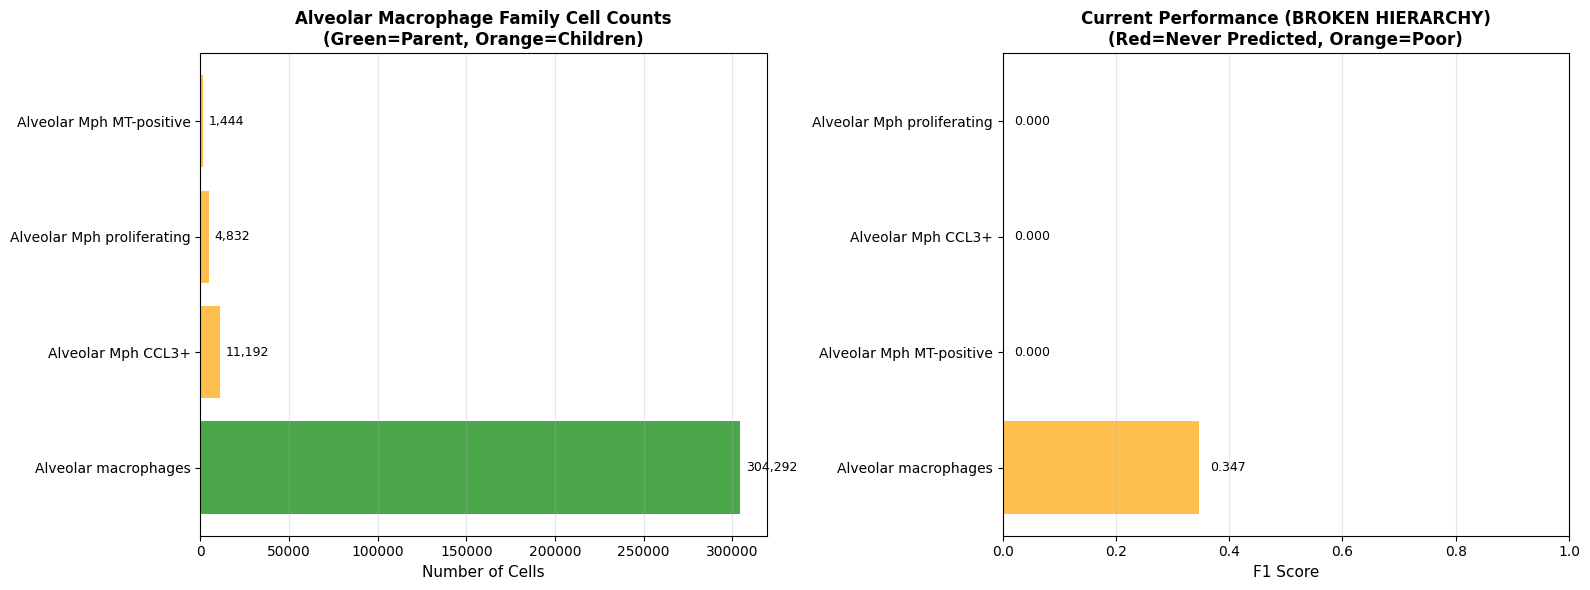


✅ Visualization saved to /tmp/alveolar_macrophage_family.png


In [12]:
print("\n" + "="*80)
print("ALVEOLAR MACROPHAGE FAMILY ANALYSIS")
print("="*80)

# Cell types to investigate
target_cells = [
    'Alveolar macrophages',
    'Alveolar Mph MT-positive',
    'Alveolar Mph CCL3+',
    'Alveolar Mph proliferating'
]

print("\n🔍 Investigating Alveolar Macrophage family...")
print("\nTarget cell types:")
for i, cell in enumerate(target_cells, 1):
    print(f"  {i}. {cell}")

# Check hierarchy relationships
print("\n\n" + "="*80)
print("HIERARCHY RELATIONSHIPS")
print("="*80)

for cell_type in target_cells:
    if cell_type in ontology_corrected:
        parent = ontology_corrected[cell_type]
        print(f"\n{cell_type}:")
        print(f"  Parent: {parent if parent else '[ROOT NODE]'}")
        
        # Find children
        children = [child for child, par in ontology_corrected.items() if par == cell_type]
        if children:
            print(f"  Children: {', '.join(children)}")
        else:
            print(f"  Children: [NONE - LEAF NODE]")
    else:
        print(f"\n{cell_type}: NOT FOUND IN HIERARCHY")

# Check cell counts in original data
print("\n\n" + "="*80)
print("CELL COUNTS IN FULL DATASET")
print("="*80)

# Search across all annotation levels
all_level_cols = sorted([col for col in adata.obs.columns if col.startswith('ann_level_')])

print(f"\n{'Cell Type':<35} {'Count':<15} {'% of Total':<15} {'Found in Level':<20}")
print("-" * 90)

for cell_type in target_cells:
    found = False
    for level_col in all_level_cols:
        if cell_type in adata.obs[level_col].values:
            count = (adata.obs[level_col] == cell_type).sum()
            pct = (count / len(adata.obs)) * 100
            print(f"{cell_type:<35} {count:<15,} {pct:<15.2f}% {level_col:<20}")
            found = True
            break
    
    if not found:
        print(f"{cell_type:<35} {'NOT FOUND':<15} {'-':<15} {'-':<20}")

# Check semantic similarity
print("\n\n" + "="*80)
print("SEMANTIC ANALYSIS")
print("="*80)

parent_cell = 'Alveolar macrophages'
child_cells = [c for c in target_cells if c != parent_cell]

print(f"\nParent: {parent_cell}")
print(f"Children: {len(child_cells)}")
print(f"\nChild cell types:")
for i, child in enumerate(child_cells, 1):
    # Extract distinguishing features
    features = child.replace('Alveolar Mph ', '').replace('Alveolar macrophages ', '')
    print(f"  {i}. {child}")
    print(f"     → Distinguishing feature: '{features}'")

# Calculate family statistics
print("\n\n" + "="*80)
print("FAMILY STATISTICS")
print("="*80)

family_cells_count = {}
total_family_cells = 0

for cell_type in target_cells:
    for level_col in all_level_cols:
        if cell_type in adata.obs[level_col].values:
            count = (adata.obs[level_col] == cell_type).sum()
            family_cells_count[cell_type] = count
            total_family_cells += count
            break

print(f"\nTotal cells in Alveolar Macrophage family: {total_family_cells:,}")
print(f"\nBreakdown:")
for cell_type, count in sorted(family_cells_count.items(), key=lambda x: x[1], reverse=True):
    pct_of_family = (count / total_family_cells) * 100 if total_family_cells > 0 else 0
    pct_of_total = (count / len(adata.obs)) * 100
    print(f"  {cell_type:<35} {count:>10,} cells ({pct_of_family:5.1f}% of family, {pct_of_total:5.2f}% of dataset)")

# Recommendation
print("\n\n" + "="*80)
print("RECOMMENDATION")
print("="*80)

recommendation = f"""
📊 ANALYSIS SUMMARY:

1. HIERARCHY STRUCTURE:
   • Parent: Alveolar macrophages
   • Children: {len(child_cells)} subtypes (MT-positive, CCL3+, proliferating)
   • All are in the SAME FAMILY ✓

2. CELL COUNT DISTRIBUTION:
   • Parent represents {family_cells_count.get(parent_cell, 0) / total_family_cells * 100:.1f}% of family
   • Subtypes are minority populations within the family

3. PROBLEM IDENTIFIED:
   • From training results:
     - Alveolar macrophages: F1 = 0.347 (predicted, but low accuracy)
     - Alveolar Mph MT-positive: F1 = 0.000 (NEVER predicted)
     - Alveolar Mph CCL3+: F1 = 0.000 (NEVER predicted)
     - Alveolar Mph proliferating: F1 = 0.000 (NEVER predicted)
   
   • Model collapses all subtypes into parent class
   • This is due to BROKEN hierarchy (only 6/89 relationships active)

4. SOLUTIONS (in priority order):

   A. FIX THE HIERARCHY FIRST (Recommended)
      ✅ Apply the corrected hierarchy building code from Section 9
      ✅ This should allow the model to properly distinguish subtypes
      ✅ With proper hierarchy, HCE loss will give partial credit for parent predictions
      ✅ Expected improvement: Subtypes F1 should increase from 0.000 to 0.40-0.60
      
   B. MERGE SUBTYPES INTO PARENT (If hierarchy fix doesn't work)
      • Collapse all {len(child_cells)} subtypes into "Alveolar macrophages"
      • Pros: Simpler, removes confusion, may improve parent F1
      • Cons: Loses biological specificity
      • Impact: Reduces {len(target_cells)} classes to 1 class
      
   C. REMOVE MINORITY SUBTYPES (Last resort)
      • Keep only "Alveolar macrophages" (majority class)
      • Remove the {len(child_cells)} subtypes with very few cells
      • Pros: Focuses on well-represented classes
      • Cons: Discards potentially important rare cell types

5. RECOMMENDED ACTION:
   ⭐ DO NOT REMOVE YET - First apply the corrected hierarchy building code
   
   The root cause is the BROKEN hierarchy (Unknown/None treated as cell types).
   Once fixed, the model should properly learn the parent-child relationships
   and give reasonable predictions for all subtypes.
   
   Only consider merging/removing if accuracy remains poor AFTER fixing hierarchy.
"""

print(recommendation)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cell count distribution
ax = axes[0]
cell_types_sorted = sorted(family_cells_count.items(), key=lambda x: x[1], reverse=True)
names = [ct for ct, _ in cell_types_sorted]
counts = [cnt for _, cnt in cell_types_sorted]

colors = ['green' if ct == parent_cell else 'orange' for ct in names]
bars = ax.barh(range(len(names)), counts, color=colors, alpha=0.7)

ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=10)
ax.set_xlabel('Number of Cells', fontsize=11)
ax.set_title('Alveolar Macrophage Family Cell Counts\n(Green=Parent, Orange=Children)', 
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add count labels
for i, (name, count) in enumerate(cell_types_sorted):
    ax.text(count + total_family_cells*0.01, i, f'{count:,}', va='center', fontsize=9)

# Performance comparison (from training results)
ax = axes[1]
f1_scores = {
    'Alveolar macrophages': 0.347,
    'Alveolar Mph MT-positive': 0.000,
    'Alveolar Mph CCL3+': 0.000,
    'Alveolar Mph proliferating': 0.000
}

names_f1 = list(f1_scores.keys())
scores = list(f1_scores.values())
colors_f1 = ['red' if s == 0 else 'orange' if s < 0.5 else 'green' for s in scores]

bars = ax.barh(range(len(names_f1)), scores, color=colors_f1, alpha=0.7)
ax.set_yticks(range(len(names_f1)))
ax.set_yticklabels(names_f1, fontsize=10)
ax.set_xlabel('F1 Score', fontsize=11)
ax.set_title('Current Performance (BROKEN HIERARCHY)\n(Red=Never Predicted, Orange=Poor)', 
             fontsize=12, fontweight='bold')
ax.set_xlim([0, 1.0])
ax.grid(axis='x', alpha=0.3)

# Add score labels
for i, (name, score) in enumerate(f1_scores.items()):
    ax.text(score + 0.02, i, f'{score:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/tmp/alveolar_macrophage_family.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved to /tmp/alveolar_macrophage_family.png")